In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds

train_raw, val_raw = tfds.load(
'cats_vs_dogs',
split=['train[:80%]', 'train[80%:]'],
as_supervised=True
)

I0000 00:00:1775858514.376300   34895 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775858514.428361   34895 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775858516.044642   34895 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

E0000 00:00:1775858820.048760   34895 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
Corrupt JPEG data: 239 extraneous bytes before marker 0xd9
Corrupt JPEG data: 214 extraneous bytes before marker 0xd9
Corrupt JPEG data: 128 extraneous bytes before marker 0xd9
Corrupt JPEG data: 99 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1153 extraneous bytes before marker 0xd9
Corrupt JPEG data: 396 extraneous bytes before marker 0xd9
Corrupt JPEG data: 228 extraneous bytes before marker 0xd9
Corrupt JPEG data: 162 extraneous bytes before marker 0xd9
Corrupt JPEG data: 1403 extraneous bytes before marker 0xd9
Corrupt JPEG data: 252 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2226 extraneous bytes before marker 0xd9
Corrupt JPEG data: 65 extraneous bytes before marker 0xd9


Shuffling /home/idavid/tensorflow_datasets/cats_vs_dogs/incomplete.JMHFYH_4.0.1/cats_vs_dogs-train.tfrecord*..…

Dataset cats_vs_dogs downloaded and prepared to /home/idavid/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


I0000 00:00:1775858870.045282   35666 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


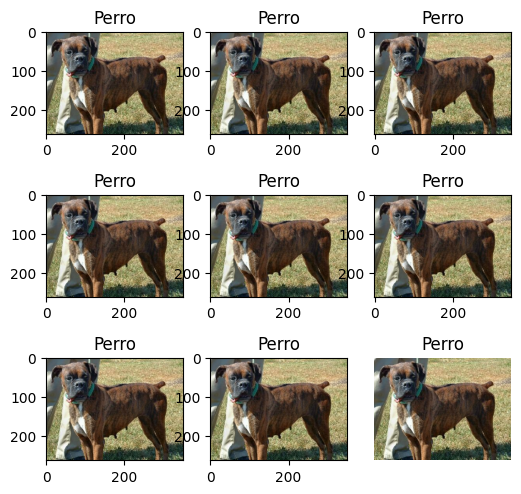

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
for images, labels in train_raw.take(1):
  for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images.numpy())
    plt.title("Perro" if labels.numpy()==1 else "Gato")
  plt.axis("off")
  plt.show()

In [3]:
IMG_SIZE = (224, 224)
batch_size = 32

def format_image(image, label):
  image = tf.image.resize(image, IMG_SIZE)
  image = image / 255.0
  return image, label

train_ds = train_raw.map(format_image).batch(batch_size).prefetch(1)
val_ds = val_raw.map(format_image).batch(batch_size).prefetch(1)

In [4]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
input_shape=IMG_SIZE + (3,),
include_top=False,
weights='imagenet'
)
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [5]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

model = Sequential([
base_model,
GlobalAveragePooling2D(),
Dense(128, activation='relu'),
Dropout(0.3),
Dense(1, activation='sigmoid')
])

In [6]:
model.compile(
 optimizer='adam',
 loss='binary_crossentropy',
 metrics=['accuracy']
)

history = model.fit(
train_ds,
validation_data=val_ds,
epochs=5
)

Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 335s 570ms/step - accuracy: 0.9780 - loss: 0.0600 - val_accuracy: 0.9847 - val_loss: 0.0425
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 339s 583ms/step - accuracy: 0.9854 - loss: 0.0403 - val_accuracy: 0.9837 - val_loss: 0.0456
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 332s 570ms/step - accuracy: 0.9883 - loss: 0.0325 - val_accuracy: 0.9850 - val_loss: 0.0448
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 331s 570ms/step - accuracy: 0.9897 - loss: 0.0282 - val_accuracy: 0.9832 - val_loss: 0.0511
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 324s 556ms/step - accuracy: 0.9923 - loss: 0.0228 - val_accuracy: 0.9854 - val_loss: 0.0487


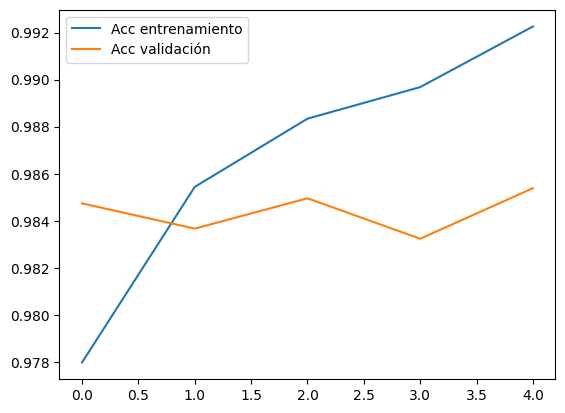

In [7]:
plt.plot(history.history['accuracy'], label='Acc entrenamiento')
plt.plot(history.history['val_accuracy'], label='Acc validación')
plt.legend()
plt.show()

In [8]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img("/content/drive/MyDrive/Colab Notebooks/Prácticas AACD/mi_imagen.jpg", target_size=IMG_SIZE)
img_array = image.img_to_array(img) / 255.0
img_array = tf.expand_dims(img_array, 0)

pred = model.predict(img_array)[0][0]
print("Predicción:", "Perro" if pred > 0.5 else "Gato")